In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')


In [2]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense


In [3]:
df = pd.read_csv('/content/archive (11).zip')


In [4]:
df.head()


,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0


In [5]:
df['diabetes'].value_counts()


,count
diabetes,
0,91500
1,8500


In [6]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   gender               100000 non-null  object 
 1   age                  100000 non-null  float64
 2   hypertension         100000 non-null  int64  
 3   heart_disease        100000 non-null  int64  
 4   smoking_history      100000 non-null  object 
 5   bmi                  100000 non-null  float64
 6   HbA1c_level          100000 non-null  float64
 7   blood_glucose_level  100000 non-null  int64  
 8   diabetes             100000 non-null  int64  
dtypes: float64(3), int64(4), object(2)
memory usage: 6.9+ MB


In [7]:
df['gender'] = LabelEncoder().fit_transform(df['gender'])
df['smoking_history'] = LabelEncoder().fit_transform(df['smoking_history'])


In [8]:
X = df.drop(columns=['diabetes'], axis=1)
y = df['diabetes']


In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


In [10]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [11]:
model = Sequential([
    Dense(16, input_dim=8, activation='relu'),
    Dense(8, activation='relu'),
    Dense(1, activation='sigmoid')
])


In [12]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)


In [13]:
history = model.fit(
    X_train_scaled,
    y_train,
    epochs=30,
    batch_size=8,
    validation_split=0.2,
    verbose=1
)


Epoch 1/30
8000/8000 ━━━━━━━━━━━━━━━━━━━━ 21s 2ms/step - accuracy: 0.9556 - loss: 0.1273 - val_accuracy: 0.9579 - val_loss: 0.1165
Epoch 2/30
8000/8000 ━━━━━━━━━━━━━━━━━━━━ 20s 2ms/step - accuracy: 0.9656 - loss: 0.1025 - val_accuracy: 0.9644 - val_loss: 0.1000
Epoch 3/30
8000/8000 ━━━━━━━━━━━━━━━━━━━━ 19s 2ms/step - accuracy: 0.9680 - loss: 0.0953 - val_accuracy: 0.9649 - val_loss: 0.0946
Epoch 4/30
8000/8000 ━━━━━━━━━━━━━━━━━━━━ 21s 3ms/step - accuracy: 0.9695 - loss: 0.0899 - val_accuracy: 0.9673 - val_loss: 0.0907
Epoch 5/30
8000/8000 ━━━━━━━━━━━━━━━━━━━━ 19s 2ms/step - accuracy: 0.9705 - loss: 0.0865 - val_accuracy: 0.9688 - val_loss: 0.0885
Epoch 6/30
8000/8000 ━━━━━━━━━━━━━━━━━━━━ 20s 3ms/step - accuracy: 0.9709 - loss: 0.0854 - val_accuracy: 0.9693 - val_loss: 0.0877
Epoch 7/30
8000/8000 ━━━━━━━━━━━━━━━━━━━━ 20s 2ms/step - accuracy: 0.9711 - loss: 0.0844 - val_accuracy: 0.9693 - val_loss: 0.0879
Epoch 8/30
8000/8000 ━━━━━━━━━━━━━━━━━━━━ 20s 3ms/step - accuracy: 0.9713 - loss: 0

In [14]:
loss, acc = model.evaluate(X_test_scaled, y_test, verbose=1)
print(acc)


625/625 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9719 - loss: 0.0815
0.9719499945640564


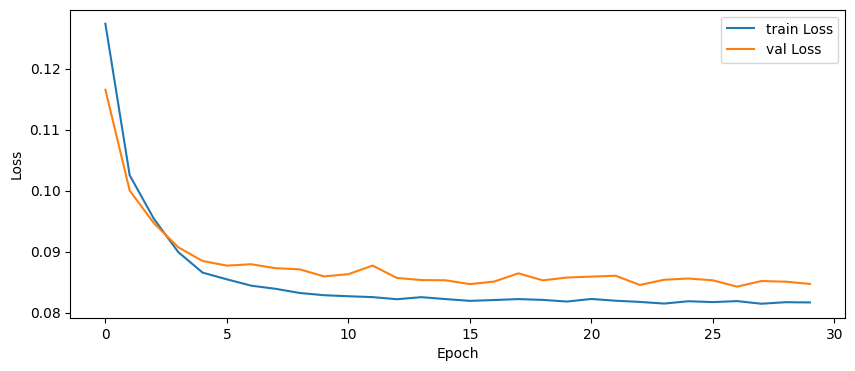

In [15]:
plt.figure(figsize=(10,4))
plt.plot(history.history['loss'], label="train Loss")
plt.plot(history.history['val_loss'], label="val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()
